# CIFAR-10 - Convolutional Network (CNN)

In [11]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [12]:
# Model / data parameters
num_classes = 10
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Convert labels from shape (N, 1) to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalize pixel values to [0, 1] - keep images as 32x32x3
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


In [13]:
# CNN model for CIFAR-10:
inputs = keras.Input(shape=input_shape)
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_cnn")

In [14]:
model.summary()

Model: "cifar10_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 2304)              

In [15]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Train model
history = model.fit(
    x_train, y_train,   
    batch_size=32,
    epochs=20,
    validation_split=0.2,
)

Epoch 1/20
1250/1250 [==============================] - 4s 3ms/step - loss: 1.6228 - accuracy: 0.4149 - val_loss: 1.3374 - val_accuracy: 0.5344
Epoch 2/20
1250/1250 [==============================] - 5s 4ms/step - loss: 1.3336 - accuracy: 0.5289 - val_loss: 1.2162 - val_accuracy: 0.5749
Epoch 3/20
1250/1250 [==============================] - 3s 3ms/step - loss: 1.2141 - accuracy: 0.5715 - val_loss: 1.1027 - val_accuracy: 0.6204
Epoch 4/20
1250/1250 [==============================] - 3s 3ms/step - loss: 1.1475 - accuracy: 0.5982 - val_loss: 1.0847 - val_accuracy: 0.6303
Epoch 5/20
1250/1250 [==============================] - 4s 3ms/step - loss: 1.0978 - accuracy: 0.6190 - val_loss: 1.0256 - val_accuracy: 0.6444
Epoch 6/20
1250/1250 [==============================] - 4s 3ms/step - loss: 1.0604 - accuracy: 0.6280 - val_loss: 1.0102 - val_accuracy: 0.6484
Epoch 7/20
1250/1250 [==============================] - 4s 4ms/step - loss: 1.0333 - accuracy: 0.6400 - val_loss: 0.9754 - val_accuracy:

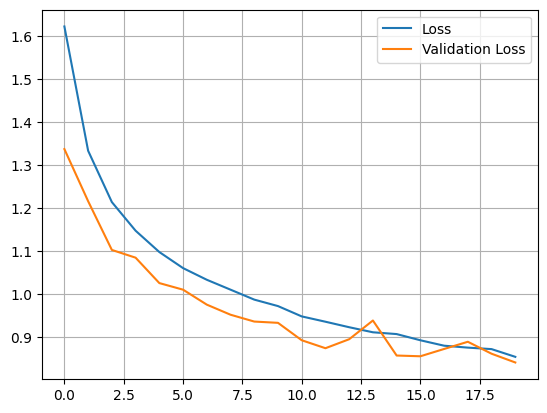

In [16]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [17]:
# Evaluate final model on unseen test data
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.8511120080947876
Test accuracy: 0.7116000056266785


313/313 [==============================] - 0s 815us/step


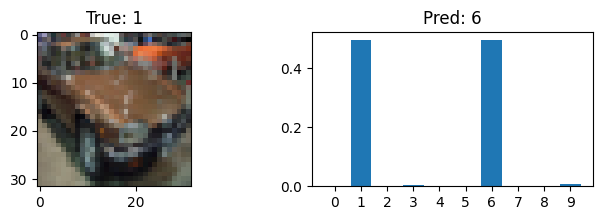

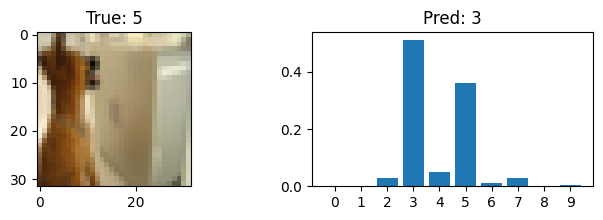

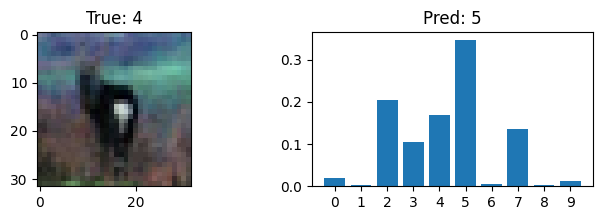

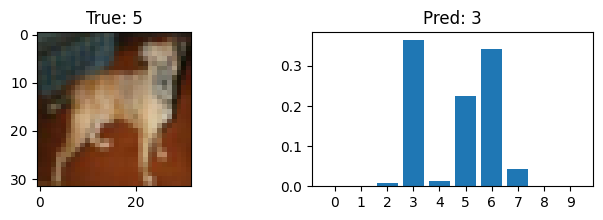

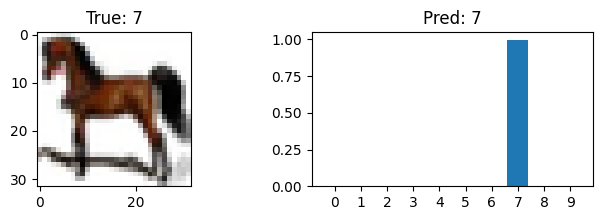

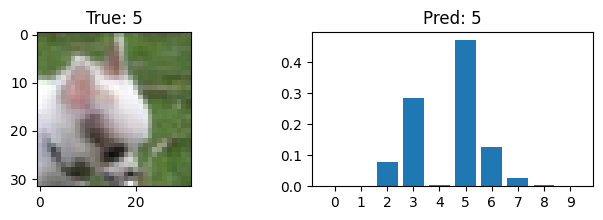

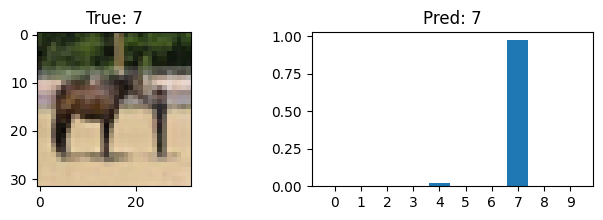

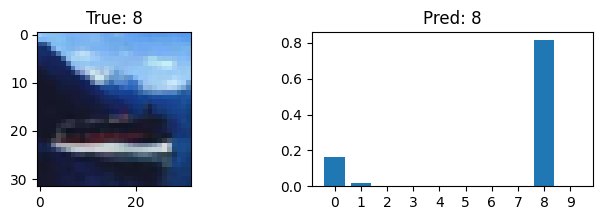

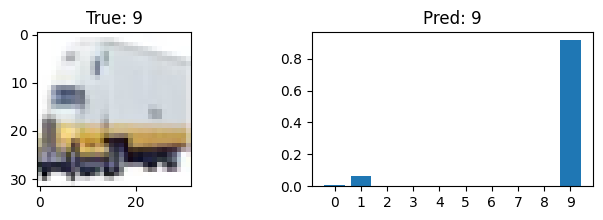

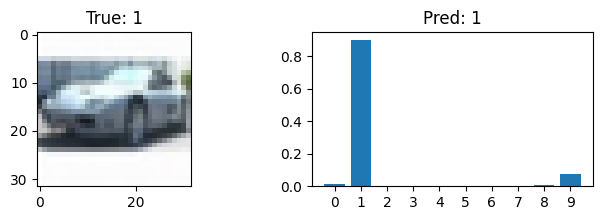

In [18]:
y_pred = model.predict(x_test)
start = 2000

# visualization
for k in range(10):
    plt.figure(figsize=(8, 2))

    plt.subplot(1,2,1)
    plt.imshow(x_test[start+k])
    plt.title(f"True: {y_test[start+k]}")

    plt.subplot(1,2,2)
    plt.bar(range(10), y_pred[start+k].flatten())
    plt.title(f"Pred: {np.argmax(y_pred[start+k])}")

    plt.xticks(range(10))
    plt.show()